Temizlik Sonrası X (Özellikler) Boyutu: (88, 305)
Artık tüm veriler sayısal! Modeli eğitmeye başlıyoruz...

🎉 Modelin Doğruluk Oranı (Accuracy): %72.22


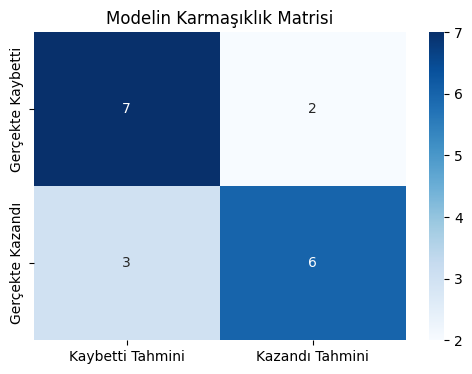

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. AŞAMA: SON VERİ TEMİZLİĞİ
# ---------------------------------------------------------
# True/False değerlerini 1 ve 0 sayılarına dönüştürüyoruz
X = X.replace({True: 1, False: 0})

# Kalan tüm 'object' (metin) türündeki sütunları bulup siliyoruz
object_cols = X.select_dtypes(include=['object']).columns
X = X.drop(columns=object_cols)

print("Temizlik Sonrası X (Özellikler) Boyutu:", X.shape)
print("Artık tüm veriler sayısal! Modeli eğitmeye başlıyoruz...\n")

# ---------------------------------------------------------
# 2. AŞAMA: EĞİTİM (TRAIN) VE TEST BÖLÜNMESİ
# ---------------------------------------------------------
# Verimizin %80'ini modele çalışması için (Train), 
# %20'sini ise kopya çekmeden kendini test etmesi için (Test) ayırıyoruz.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ---------------------------------------------------------
# 3. AŞAMA: MODELİ KURMA VE EĞİTME
# ---------------------------------------------------------
# Güçlü bir Sınıflandırma algoritması olan Random Forest (Rastgele Orman) kullanıyoruz
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Model, X_train verilerine bakarak y_train sonuçlarını öğreniyor
model.fit(X_train, y_train)

# ---------------------------------------------------------
# 4. AŞAMA: TAHMİN YAPMA VE BAŞARI ÖLÇÜMÜ
# ---------------------------------------------------------
# Modelden hiç görmediği X_test verilerini tahmin etmesini istiyoruz
y_pred = model.predict(X_test)

# Tahminleri gerçek sonuçlarla (y_test) karşılaştırıp başarı oranını buluyoruz
accuracy = accuracy_score(y_test, y_pred)
print(f"🎉 Modelin Doğruluk Oranı (Accuracy): %{accuracy * 100:.2f}")

# Modelin nerede kafasının karıştığını görmek için Karmaşıklık Matrisi (Confusion Matrix) çizdiriyoruz
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Kaybetti Tahmini', 'Kazandı Tahmini'], yticklabels=['Gerçekte Kaybetti', 'Gerçekte Kazandı'])
plt.title('Modelin Karmaşıklık Matrisi')
plt.show()

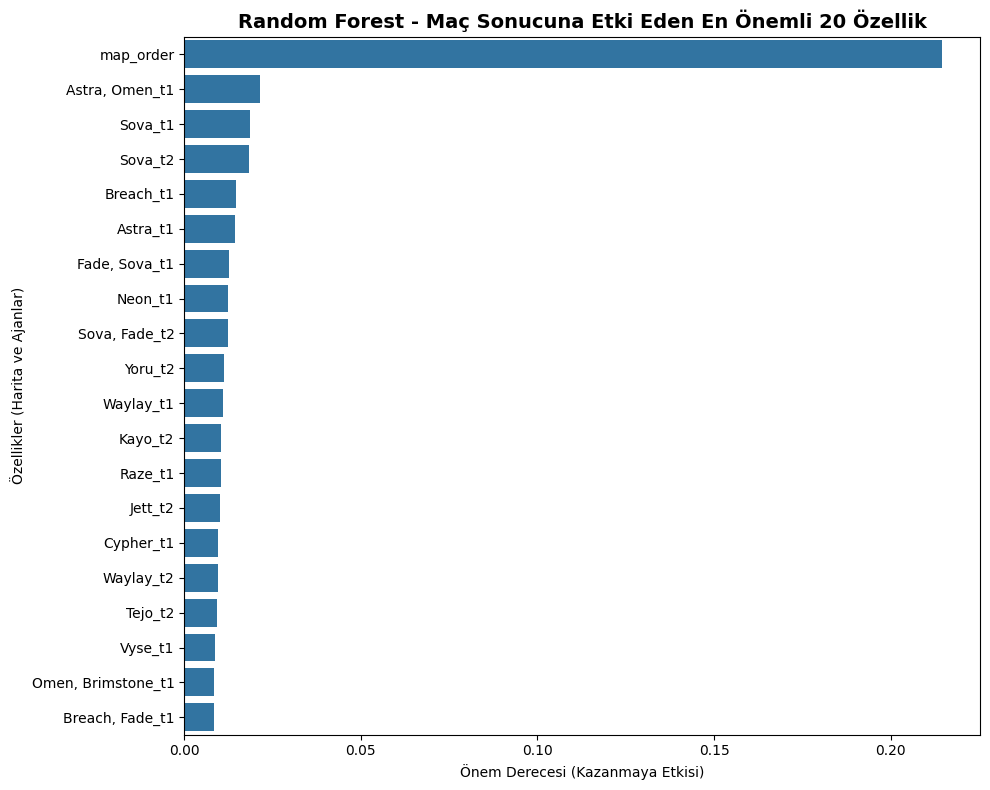

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Modelin içindeki önem derecelerini çekelim
importances = model.feature_importances_

# 2. Bu dereceleri, X tablomuzdaki sütun isimleriyle eşleştirelim
feature_imp_df = pd.DataFrame({
    'Özellik': X.columns,
    'Önem_Derecesi': importances
})

# 3. Yüzlerce özellik var, biz en çok etki eden ilk 20'yi bulup sıralayalım
top_20_features = feature_imp_df.sort_values(by='Önem_Derecesi', ascending=False).head(20)

# 4. Veriyi Görselleştirelim
plt.figure(figsize=(10, 8))
sns.barplot(x='Önem_Derecesi', y='Özellik', data=top_20_features)

plt.title('Random Forest - Maç Sonucuna Etki Eden En Önemli 20 Özellik', fontsize=14, fontweight='bold')
plt.xlabel('Önem Derecesi (Kazanmaya Etkisi)')
plt.ylabel('Özellikler (Harita ve Ajanlar)')
plt.tight_layout()
plt.show()

In [17]:
import joblib

# 1. Eğittiğimiz Random Forest modelini kaydedelim
joblib.dump(model, 'valorant_rf_model.pkl')

# 2. ÇOK KRİTİK: Modelin eğitimde gördüğü X tablosunun sütun isimlerini de kaydetmeliyiz.
# Çünkü kullanıcı web arayüzünde sadece 10 ajan seçecek, ancak modelimiz 
# eğitim sırasında yüzlerce '0' ve '1' sütunu gördü. Arayüzde bu yapıyı birebir kurmamız gerekecek.
joblib.dump(list(X.columns), 'model_columns.pkl')

print("Model (valorant_rf_model.pkl) ve Sütun Yapısı (model_columns.pkl) başarıyla kaydedildi!")

Model (valorant_rf_model.pkl) ve Sütun Yapısı (model_columns.pkl) başarıyla kaydedildi!
